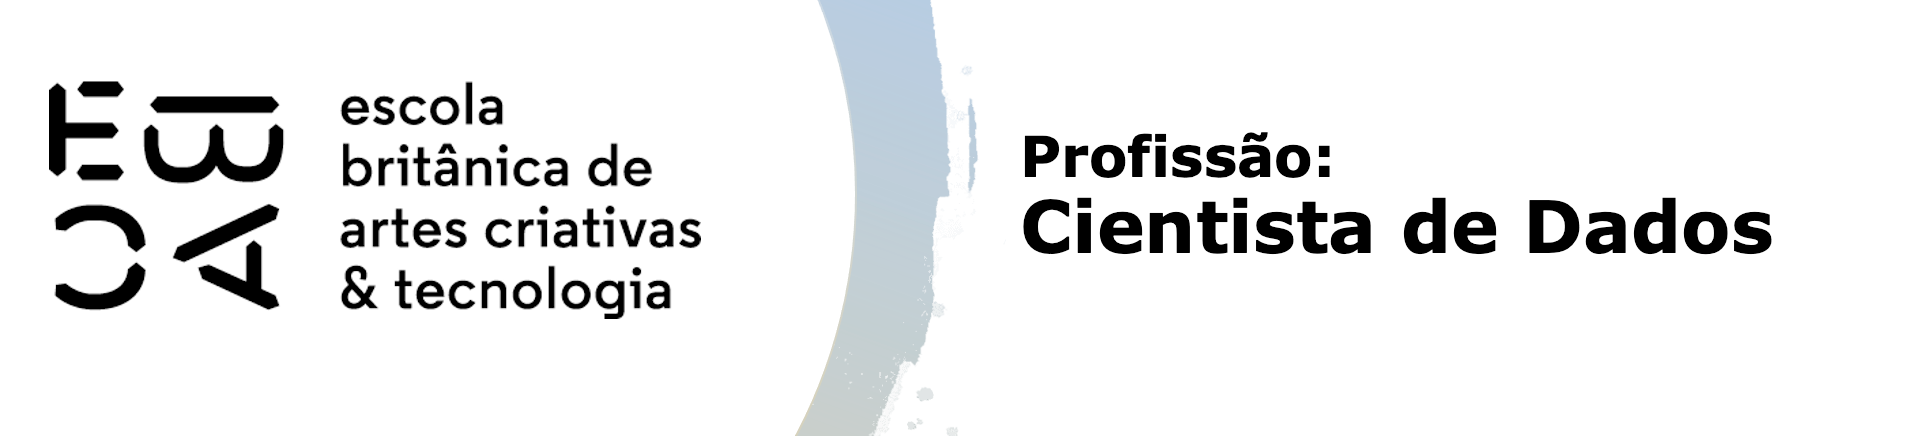

# Tarefa I

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [2]:
# Garantir que data_ref está em datetime
df['data_ref'] = pd.to_datetime(df['data_ref'])

# Criar a "safra" como mês
df['safra_mes'] = df['data_ref'].dt.to_period('M').dt.to_timestamp()

# Listar as 3 últimas safras
ultimas_3_safras = sorted(df['safra_mes'].unique())[-3:]

# OOT = últimas 3 safras
df_oot = df[df['safra_mes'].isin(ultimas_3_safras)].copy()

# Treino/desenvolvimento = todo o resto
df_treino = df[~df['safra_mes'].isin(ultimas_3_safras)].copy()

print("Safras OOT:", ultimas_3_safras)
print("Linhas treino:", df_treino.shape[0])
print("Linhas OOT:", df_oot.shape[0])


print("Treino - intervalo de datas:", df_treino['data_ref'].min(), "até", df_treino['data_ref'].max())
print("OOT    - intervalo de datas:", df_oot['data_ref'].min(), "até", df_oot['data_ref'].max())

# Quantidade por safra (para confirmar)
display(df_treino['safra_mes'].value_counts().sort_index())
display(df_oot['safra_mes'].value_counts().sort_index())


Safras OOT: [numpy.datetime64('2016-01-01T00:00:00.000000000'), numpy.datetime64('2016-02-01T00:00:00.000000000'), numpy.datetime64('2016-03-01T00:00:00.000000000')]
Linhas treino: 600000
Linhas OOT: 150000
Treino - intervalo de datas: 2015-01-01 00:00:00 até 2015-12-01 00:00:00
OOT    - intervalo de datas: 2016-01-01 00:00:00 até 2016-03-01 00:00:00


2015-01-01    50000
2015-02-01    50000
2015-03-01    50000
2015-04-01    50000
2015-05-01    50000
2015-06-01    50000
2015-07-01    50000
2015-08-01    50000
2015-09-01    50000
2015-10-01    50000
2015-11-01    50000
2015-12-01    50000
Name: safra_mes, dtype: int64

2016-01-01    50000
2016-02-01    50000
2016-03-01    50000
Name: safra_mes, dtype: int64

## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [3]:
print(f"Número total de observações: {df.shape[0]}")
print(f"Número total de variáveis: {df.shape[1]}")

Número total de observações: 750000
Número total de variáveis: 16


In [4]:
# Criar variável mensal
df['mes_ref'] = df['data_ref'].dt.to_period('M').dt.to_timestamp()

# Contagem por mês
obs_por_mes = (
    df.groupby('mes_ref')
      .size()
      .reset_index(name='qtd_observacoes')
)

display(obs_por_mes)

,mes_ref,qtd_observacoes
0,2015-01-01,50000
1,2015-02-01,50000
2,2015-03-01,50000
3,2015-04-01,50000
4,2015-05-01,50000
5,2015-06-01,50000
6,2015-07-01,50000
7,2015-08-01,50000
8,2015-09-01,50000
9,2015-10-01,50000


In [5]:
variaveis_qualitativas = df.select_dtypes(include=['object']).columns.tolist()
variaveis_quantitativas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
variaveis_quantitativas.remove('index')


print("Variáveis qualitativas:")
print(variaveis_qualitativas)

print("\nVariáveis quantitativas:")
print(variaveis_quantitativas)


Variáveis qualitativas:
['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']

Variáveis quantitativas:
['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']


In [6]:
df[variaveis_quantitativas].describe().T

,count,mean,std,min,25%,50%,75%,max
qtd_filhos,750000.0,0.433251,0.739379,0.000000,0.000000,0.000000,1.000000,1.400000e+01
idade,750000.0,43.804733,11.229868,22.000000,34.000000,43.000000,53.000000,6.800000e+01
tempo_emprego,624043.0,7.748574,6.687455,0.117808,3.049315,6.046575,10.183562,4.290685e+01
qt_pessoas_residencia,750000.0,2.212241,0.903428,1.000000,2.000000,2.000000,3.000000,1.500000e+01
renda,750000.0,23238.544747,79106.013795,107.670000,3467.700000,7861.820000,18318.280000,4.083986e+06


In [7]:
for col in variaveis_qualitativas:
    print(f"\nVariável: {col}")
    print(
        df[col]
        .value_counts(normalize=True)
        .rename('proporcao')
        .mul(100)
        .round(2)
        .reset_index()
        .rename(columns={'index': col})
    )


Variável: sexo
  sexo  proporcao
0    F      67.28
1    M      32.72

Variável: posse_de_veiculo
  posse_de_veiculo  proporcao
0                N      61.06
1                S      38.94

Variável: posse_de_imovel
  posse_de_imovel  proporcao
0               S      67.16
1               N      32.84

Variável: tipo_renda
         tipo_renda  proporcao
0       Assalariado      51.43
1        Empresário      23.03
2       Pensionista      16.84
3  Servidor público       8.66
4          Bolsista       0.05

Variável: educacao
              educacao  proporcao
0                Médio      67.58
1    Superior completo      27.24
2  Superior incompleto       3.93
3          Fundamental       1.14
4        Pós graduação       0.11

Variável: estado_civil
  estado_civil  proporcao
0       Casado      70.20
1     Solteiro      12.22
2        União       7.69
3     Separado       5.68
4        Viúvo       4.22

Variável: tipo_residencia
  tipo_residencia  proporcao
0            Casa      89.91
1

<font color="orange">
De forma geral, observa-se que a base é composta majoritariamente por um perfil relativamente homogêneo: predominam mulheres, pessoas casadas, com ensino médio completo, renda principalmente assalariada e residência própria do tipo casa. Nota-se também uma maior proporção de indivíduos sem veículo, apesar da elevada taxa de posse de imóvel, o que pode refletir características específicas do público analisado. As categorias minoritárias (como bolsistas, pós-graduação e tipos alternativos de residência) representam parcelas muito pequenas da amostra, o que sugere cautela na interpretação de resultados associados a esses grupos devido ao baixo volume de observações.
</font>


## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

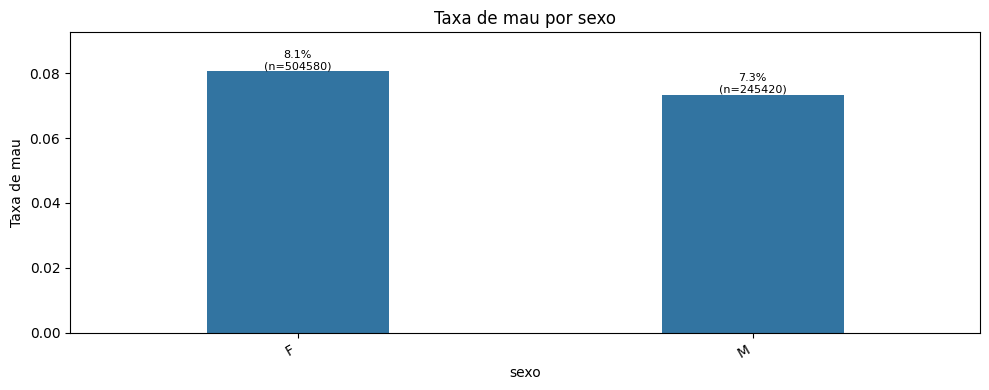

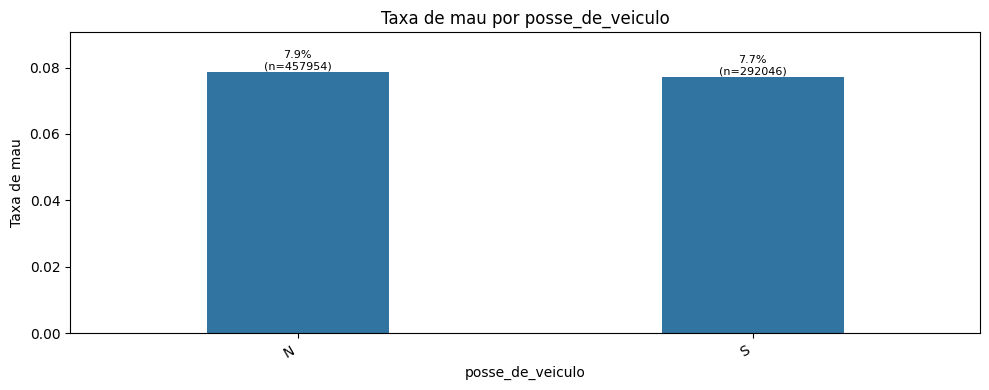

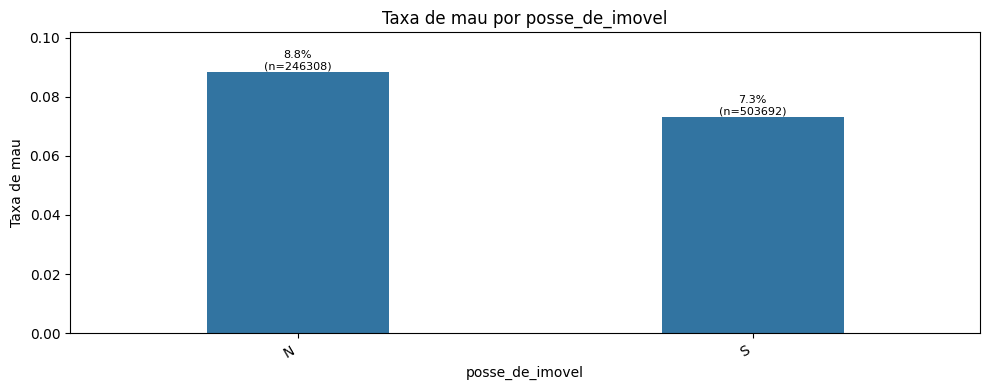

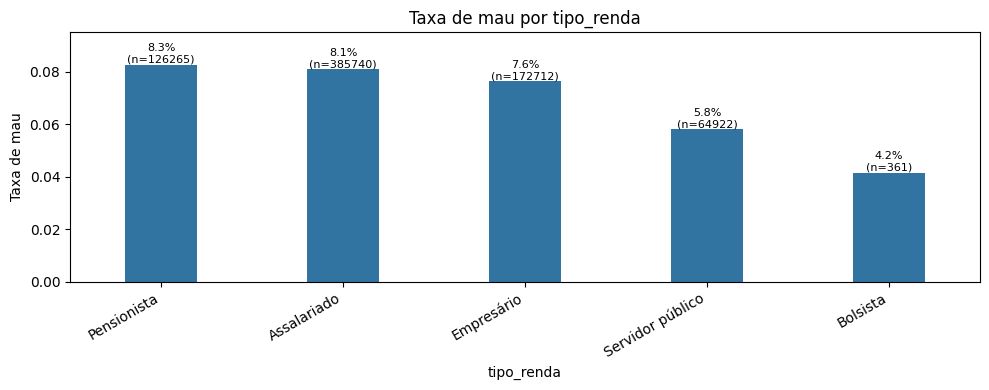

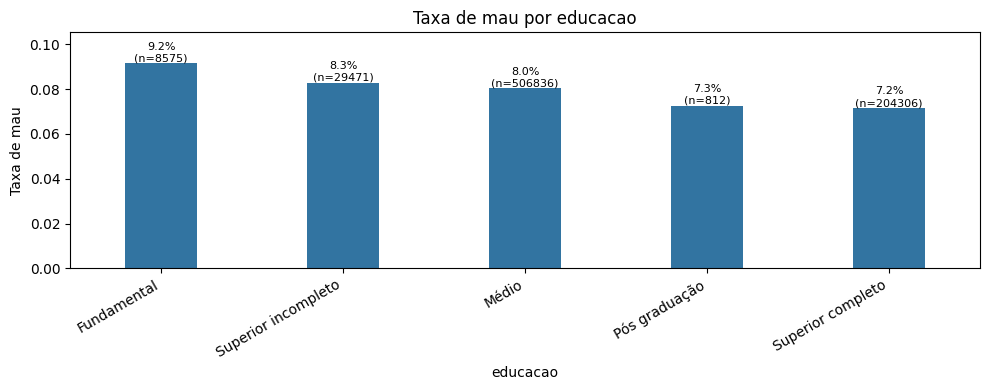

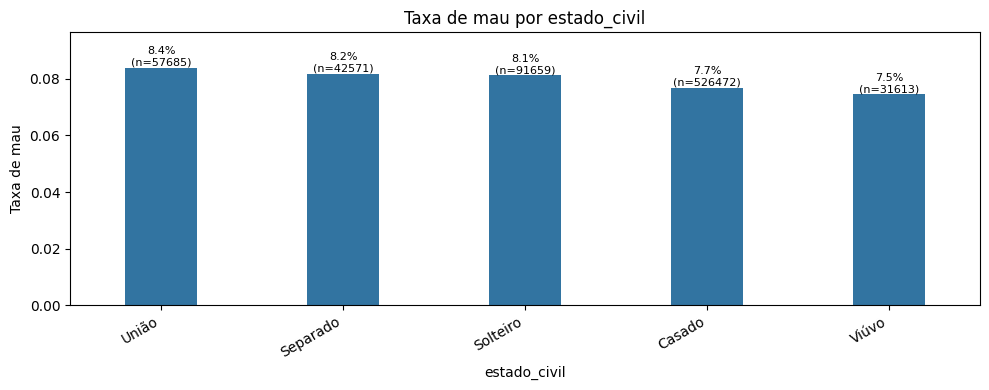

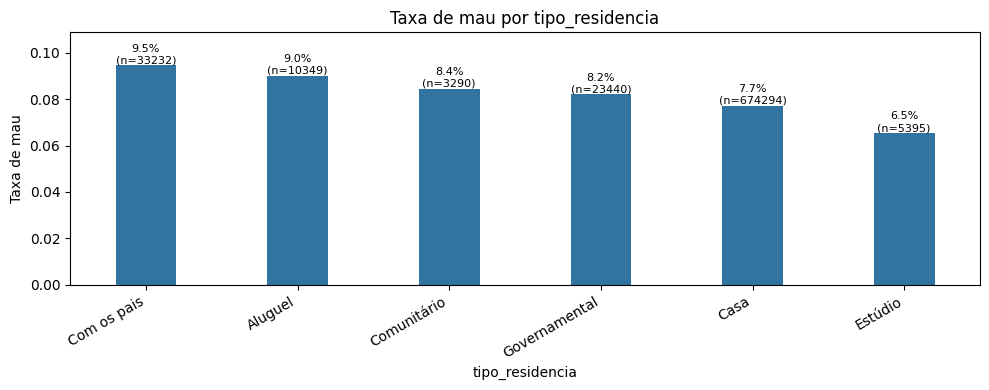

In [8]:
qualitativas = ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']

target = 'mau'

for col in qualitativas:
    tmp = (df
           .groupby(col)[target]
           .agg(qtd='size', taxa_mau='mean')
           .reset_index()
           .sort_values('taxa_mau', ascending=False))

    plt.figure(figsize=(10, 4))
    ax = sns.barplot(data=tmp, x=col, y='taxa_mau',width=0.4)
    plt.title(f"Taxa de mau por {col}")
    plt.ylabel("Taxa de mau")
    plt.xlabel(col)
    plt.xticks(rotation=30, ha='right')
    y_max = tmp['taxa_mau'].max()
    plt.ylim(0, y_max * 1.15)  # 15% de folga acima do máximo


    # rótulo com % e volume
    for i, row in tmp.reset_index(drop=True).iterrows():
        ax.text(i, row['taxa_mau'], f"{row['taxa_mau']*100:.1f}%\n(n={int(row['qtd'])})",
                ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()


<font color="orange">
A análise bivariada das variáveis qualitativas em relação à taxa de mau indica a existência de algumas pequenas diferenças dentro de cada grupo. Observa-se um risco um pouco maior em perfis associados a menor estabilidade socioeconômica, como menor nível educacional, ausência de imóvel próprio, determinados tipos de residência e categorias específicas de renda. Variáveis como sexo e posse de veículo apresentam diferenças mais sutis, sugerindo baixo poder discriminatório. Os resultados reforçam que essas variáveis contribuem mais como componentes complementares de um modelo do que como fortes discriminadores individuais de inadimplência.
</font>


## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [9]:
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score

# Configurações iniciais

target = 'mau'

num_cols = [
    'qtd_filhos', 'idade', 'tempo_emprego',
    'qt_pessoas_residencia', 'renda'
]

cat_binarias = [
    'sexo', 'posse_de_veiculo', 'posse_de_imovel'
]

cat_multiclasse = [
    'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia'
]

# Cópias das bases
train = df_treino.copy()
oot   = df_oot.copy()


# 1) Tratamento de missings

# Numéricas: mediana do treino
medianas = {}
for c in num_cols:
    train[c] = pd.to_numeric(train[c], errors='coerce')
    oot[c]   = pd.to_numeric(oot[c], errors='coerce')

    medianas[c] = train[c].median()
    train[c] = train[c].fillna(medianas[c])
    oot[c]   = oot[c].fillna(medianas[c])

# Categóricas: Missing
for c in cat_binarias + cat_multiclasse:
    train[c] = train[c].astype('object').fillna('Missing')
    oot[c]   = oot[c].astype('object').fillna('Missing')


# 2) Tratamento de outliers

def winsorize_series(s, p_low=0.01, p_high=0.99):
    lo, hi = s.quantile([p_low, p_high])
    return s.clip(lo, hi), lo, hi

wins_limits = {}
for c in num_cols:
    train[c], lo, hi = winsorize_series(train[c], 0.01, 0.99)
    wins_limits[c] = (lo, hi)
    oot[c] = oot[c].clip(lo, hi)

# 3) Zeros estruturais

for base in [train, oot]:
    base['tempo_emprego_zero'] = (base['tempo_emprego'] == 0).astype(int)
    base['renda_zero'] = (base['renda'] == 0).astype(int)
    base['log_renda'] = np.log1p(base['renda'])

In [10]:
for col in cat_multiclasse:
    so_treino = sorted(set(train[col].unique()) - set(oot[col].unique()))
    so_oot    = sorted(set(oot[col].unique()) - set(train[col].unique()))

    print(f"\n{col}")
    print("  Só no treino:", so_treino[:20], "..." if len(so_treino) > 20 else "")
    print("  Só no OOT:  ", so_oot[:20], "..." if len(so_oot) > 20 else "")



tipo_renda
  Só no treino: [] 
  Só no OOT:   [] 

educacao
  Só no treino: [] 
  Só no OOT:   [] 

estado_civil
  Só no treino: [] 
  Só no OOT:   [] 

tipo_residencia
  Só no treino: [] 
  Só no OOT:   [] 


In [11]:
cat_multiclasse = ['tipo_renda', 'educacao', 'tipo_residencia']

for col in cat_multiclasse:
    tab = pd.concat([
        train[col].value_counts(dropna=False).rename('qtd_treino'),
        train[col].value_counts(normalize=True, dropna=False).mul(100).round(2).rename('%_treino'),
        oot[col].value_counts(dropna=False).rename('qtd_oot'),
        oot[col].value_counts(normalize=True, dropna=False).mul(100).round(2).rename('%_oot')
    ], axis=1).fillna(0)

    tab['so_treino'] = (tab['qtd_treino'] > 0) & (tab['qtd_oot'] == 0)
    tab['so_oot']    = (tab['qtd_oot'] > 0) & (tab['qtd_treino'] == 0)

    tab = tab.sort_values(['%_treino','%_oot'], ascending=False)

    print(f"\n===== {col} =====")
    display(tab.head(30))


===== tipo_renda =====


,qtd_treino,%_treino,qtd_oot,%_oot,so_treino,so_oot
Assalariado,308460,51.41,77280,51.52,False,False
Empresário,138141,23.02,34571,23.05,False,False
Pensionista,101127,16.85,25138,16.76,False,False
Servidor público,51981,8.66,12941,8.63,False,False
Bolsista,291,0.05,70,0.05,False,False



===== educacao =====


,qtd_treino,%_treino,qtd_oot,%_oot,so_treino,so_oot
Médio,405449,67.57,101387,67.59,False,False
Superior completo,163440,27.24,40866,27.24,False,False
Superior incompleto,23559,3.93,5912,3.94,False,False
Fundamental,6901,1.15,1674,1.12,False,False
Pós graduação,651,0.11,161,0.11,False,False



===== tipo_residencia =====


,qtd_treino,%_treino,qtd_oot,%_oot,so_treino,so_oot
Casa,539336,89.89,134958,89.97,False,False
Com os pais,26730,4.46,6502,4.33,False,False
Governamental,18742,3.12,4698,3.13,False,False
Aluguel,8262,1.38,2087,1.39,False,False
Estúdio,4296,0.72,1099,0.73,False,False
Comunitário,2634,0.44,656,0.44,False,False


<font color="orange">
A categoria “Bolsista” apresentou baixa representatividade na base de treino e não estava presente de forma consistente entre as safras. O mesmo ocorreu com os níveis de escolaridade "Fundamental" e "Pós graduação", além dos tipos de residência "Aluguel", "Comunitário" e "Estúdio". Para garantir estabilidade do modelo e evitar problemas de extrapolação no conjunto out of time, essas categorias foram agrupadas como “Outros”.
</font>

In [12]:
# 4) Agrupamento de categorias de menor frequência

def agrupar_com_ref(serie_treino, serie_aplicar, min_pct=0.02):
    freq = serie_treino.value_counts(normalize=True)
    raras = freq[freq < min_pct].index
    return serie_aplicar.where(~serie_aplicar.isin(raras), other='Outros')

for c in cat_multiclasse:
    train[c] = agrupar_com_ref(train[c], train[c], min_pct=0.02)
    oot[c]   = agrupar_com_ref(train[c], oot[c],   min_pct=0.02)

cat_multiclasse = ['tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']

for col in cat_multiclasse:
    niveis_treino = set(train[col].dropna().unique())
    
    # qualquer nível do OOT que não exista no treino vira "Outros"
    oot[col] = oot[col].where(oot[col].isin(niveis_treino), other='Outros')


# 5) get_dummies SOMENTE para binárias

train_dum = pd.get_dummies(
    train,
    columns=cat_binarias,
    drop_first=True
)

oot_dum = pd.get_dummies(
    oot,
    columns=cat_binarias,
    drop_first=True
)

# Alinhar colunas treino x OOT
train_dum, oot_dum = train_dum.align(
    oot_dum, join='left', axis=1, fill_value=0
)

# 6) Garantir target binário 0/1

train_dum[target] = train_dum[target].astype(int)
oot_dum[target]   = oot_dum[target].astype(int)

# Colunas numéricas/dummies com variância zero (constantes)
cols_constantes = [c for c in train_dum.columns if c != 'mau' and train_dum[c].nunique(dropna=False) <= 1]

train_dum = train_dum.drop(columns=cols_constantes, errors='ignore')
oot_dum   = oot_dum.drop(columns=cols_constantes, errors='ignore')


# 7) Regressão logística (Logit)

formula = """
mau ~ idade + tempo_emprego + qt_pessoas_residencia + qtd_filhos
      + log_renda +
      + sexo_M + posse_de_veiculo_S + posse_de_imovel_S
      + C(tipo_renda) + C(educacao) + C(estado_civil) + C(tipo_residencia)
"""

modelo_logit = smf.logit(formula=formula, data=train_dum).fit(disp=False)
print(modelo_logit.summary())


# 8) Diagnóstico de significância

nao_significantes = modelo_logit.pvalues[modelo_logit.pvalues > 0.05].sort_values()
print("\nTermos NÃO significantes (p > 0.05):")
print(nao_significantes)


                           Logit Regression Results                           
Dep. Variable:                    mau   No. Observations:               600000
Model:                          Logit   Df Residuals:                   599977
Method:                           MLE   Df Model:                           22
Date:                Mon, 30 Mar 2026   Pseudo R-squ.:                  0.1272
Time:                        09:15:57   Log-Likelihood:            -1.2040e+05
converged:                       True   LL-Null:                   -1.3794e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               6.2845      0.179     35.029      0.000       5.933       6.636
C(tipo_renda)[T.Empresário]            -0.0060      0.01

## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

In [13]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

target = "mau"

# Função KS (ranking)
def ks_stat(y_true, y_score):
    tmp = pd.DataFrame({"y": y_true, "score": y_score}).dropna().sort_values("score")
    tmp["cum_bad"]  = (tmp["y"] == 1).cumsum() / (tmp["y"] == 1).sum()
    tmp["cum_good"] = (tmp["y"] == 0).cumsum() / (tmp["y"] == 0).sum()
    return float((tmp["cum_bad"] - tmp["cum_good"]).abs().max())

# Faixa de aceitação ótima (KS máximo por corte)
def find_best_acceptance_threshold_by_ks(y_true, y_score):
    tmp = pd.DataFrame({"y": y_true, "score": y_score}).dropna()
    thresholds = np.sort(tmp["score"].unique())

    best_th, best_ks = None, -np.inf
    for th in thresholds:
        y_pred = (tmp["score"] >= th).astype(int)

        tp = ((y_pred == 1) & (tmp["y"] == 1)).sum()
        fn = ((y_pred == 0) & (tmp["y"] == 1)).sum()
        fp = ((y_pred == 1) & (tmp["y"] == 0)).sum()
        tn = ((y_pred == 0) & (tmp["y"] == 0)).sum()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        ks_cut = abs(tpr - fpr)

        if ks_cut > best_ks:
            best_ks = ks_cut
            best_th = th

    return float(best_th), float(best_ks)

# Scores do modelo
train_dum['score'] = modelo_logit.predict(train_dum)
oot_dum['score']   = modelo_logit.predict(oot_dum)

# Métricas de ranking
auc_dev = roc_auc_score(train_dum[target], train_dum['score'])
auc_oot = roc_auc_score(oot_dum[target],   oot_dum['score'])

gini_dev = 2 * auc_dev - 1
gini_oot = 2 * auc_oot - 1

ks_dev = ks_stat(train_dum[target], train_dum['score'])
ks_oot = ks_stat(oot_dum[target],   oot_dum['score'])

# Faixa de aceitação ótima
faixa_aceitacao_otima, ks_cut_dev = find_best_acceptance_threshold_by_ks(
    train_dum[target], train_dum['score']
)

resultado_ranking = pd.DataFrame({
    "Base": ["Desenvolvimento", "OOT"],
    "AUC": [auc_dev, auc_oot],
    "Gini": [gini_dev, gini_oot],
    "KS": [ks_dev, ks_oot],
})

print("Métricas de ranking:")
print(resultado_ranking.to_string(index=False, float_format="%.4f"))

print(f"\nFaixa de aceitação ótima: {faixa_aceitacao_otima:.4f}")



Métricas de ranking:
           Base    AUC   Gini     KS
Desenvolvimento 0.7702 0.5403 0.3985
            OOT 0.7377 0.4753 0.3464

Faixa de aceitação ótima: 0.0621


<font color="orange">
Os resultados indicam que o modelo apresenta poder discriminante moderado, com AUC de 0,77, Gini de 0,54 e KS de 0,40 na base de desenvolvimento. Na base out of time, observa-se uma redução dessas métricas (AUC = 0,74, Gini = 0,48 e KS = 0,35), o que é esperado devido a mudanças temporais no perfil da população e confirma ausência de overfitting severo. A manutenção de um KS relativamente elevado no OOT sugere que o modelo preserva capacidade de ordenação de risco ao longo do tempo.

A faixa de aceitação ótima estimada no desenvolvimento (≈ 6,2%) representa o ponto de corte que maximiza a separação estatística entre bons e maus pagadores (KS máximo), mas não deve ser interpretada como uma regra de decisão final. Esse resultado reforça que o modelo atua principalmente como um instrumento de ordenação de risco, enquanto a definição do ponto de corte adequado deve ser realizada pelo negócio, considerando objetivos de aprovação, apetite a risco e contexto econômico.
</font>


# a - Criar um pipeline utilizando o sklearn pipeline para o preprocessamento 

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

In [14]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from pycaret.classification import *


In [15]:
df.isna().sum().sort_values(ascending=False)

tempo_emprego            125957
data_ref                      0
tipo_residencia               0
safra_mes                     0
mau                           0
renda                         0
qt_pessoas_residencia         0
idade                         0
estado_civil                  0
index                         0
educacao                      0
tipo_renda                    0
qtd_filhos                    0
posse_de_imovel               0
posse_de_veiculo              0
sexo                          0
mes_ref                       0
dtype: int64

In [16]:
(df.isna().mean() * 100).sort_values(ascending=False)

tempo_emprego            16.794267
data_ref                  0.000000
tipo_residencia           0.000000
safra_mes                 0.000000
mau                       0.000000
renda                     0.000000
qt_pessoas_residencia     0.000000
idade                     0.000000
estado_civil              0.000000
index                     0.000000
educacao                  0.000000
tipo_renda                0.000000
qtd_filhos                0.000000
posse_de_imovel           0.000000
posse_de_veiculo          0.000000
sexo                      0.000000
mes_ref                   0.000000
dtype: float64

In [17]:
cols_com_nan = df.columns[df.isna().any()]

df[cols_com_nan].dtypes

num_cols_nan = df[cols_com_nan].select_dtypes(include=["int64", "float64"]).columns
cat_cols_nan = df[cols_com_nan].select_dtypes(include=["object", "category"]).columns

num_cols_nan, cat_cols_nan

(Index(['tempo_emprego'], dtype='object'), Index([], dtype='object'))

In [18]:
df[num_cols_nan].describe()


,tempo_emprego
count,624043.000000
mean,7.748574
std,6.687455
min,0.117808
25%,3.049315
50%,6.046575
75%,10.183562
max,42.906849


In [19]:
df[num_cols_nan].skew()


tempo_emprego    1.672302
dtype: float64

In [20]:
df.groupby('tipo_renda')['tempo_emprego'].median()

tipo_renda
Assalariado          5.964384
Bolsista            10.695890
Empresário           5.386301
Pensionista          6.049315
Servidor público     8.893151
Name: tempo_emprego, dtype: float64

In [21]:
df.groupby('tipo_renda')['tempo_emprego'].apply(lambda x: x.isna().sum())

tipo_renda
Assalariado              0
Bolsista                 0
Empresário               0
Pensionista         125957
Servidor público         0
Name: tempo_emprego, dtype: int64

In [22]:
df.groupby('tipo_renda')['tempo_emprego'].apply(lambda x: x.isna().mean())

tipo_renda
Assalariado         0.000000
Bolsista            0.000000
Empresário          0.000000
Pensionista         0.997561
Servidor público    0.000000
Name: tempo_emprego, dtype: float64

In [23]:
df.loc[df['tipo_renda'] == 'Pensionista', 'tempo_emprego'].unique()

array([        nan,  7.52054795,  6.04931507, 10.08219178,  3.63013699,
        1.60547945,  1.69863014, 15.1260274 ])

In [24]:
df['tempo_emprego_missing'] = df['tempo_emprego'].isna().astype(int)
df['tempo_emprego'] = df['tempo_emprego'].fillna(0)

df.isna().sum().sort_values(ascending=False)

data_ref                 0
index                    0
mes_ref                  0
safra_mes                0
mau                      0
renda                    0
qt_pessoas_residencia    0
tempo_emprego            0
idade                    0
tipo_residencia          0
estado_civil             0
educacao                 0
tipo_renda               0
qtd_filhos               0
posse_de_imovel          0
posse_de_veiculo         0
sexo                     0
tempo_emprego_missing    0
dtype: int64

<font color="orange">

A variável `tempo_emprego` apresentou aproximadamente 17% de valores ausentes. Ao investigar a distribuição desses valores por tipo_renda, observou-se que cerca de 99,8% dos valores da categoria Pensionista são NaNs.

Isso indica que a ausência de informação não ocorre de forma aleatória, mas sim de maneira estrutural, uma vez que pensionistas, em geral, não possuem vínculo empregatício ativo.

Dessa forma, optou-se por:

- Criar uma "flag" (`tempo_emprego_missing`) para capturar a informação associada à ausência do dado;

- Substituir os valores ausentes por zero, permitindo o uso da variável em modelos que não aceitam valores nulos.

Essa abordagem preserva a informação implícita na ausência do dado, evita distorções na distribuição da variável e reduz o risco de introdução de viés decorrente de imputações inadequadas.
</font>

### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

In [25]:
df[num_cols].describe(percentiles=[0.01, 0.05, 0.95, 0.99])

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda
count,750000.000000,750000.000000,750000.000000,750000.000000,7.500000e+05
mean,0.433251,43.804733,6.447258,2.212241,2.323854e+04
std,0.739379,11.229868,6.752868,0.903428,7.910601e+04
min,0.000000,22.000000,0.000000,1.000000,1.076700e+02
1%,0.000000,25.000000,0.000000,1.000000,5.974200e+02
5%,0.000000,27.000000,0.000000,1.000000,1.190330e+03
50%,0.000000,43.000000,4.690411,2.000000,7.861820e+03
95%,2.000000,63.000000,20.216438,4.000000,7.689261e+04
99%,3.000000,66.000000,30.567123,5.000000,2.868769e+05
max,14.000000,68.000000,42.906849,15.000000,4.083986e+06


In [26]:
df[df['qt_pessoas_residencia'] > 5]['qt_pessoas_residencia'].value_counts()

6.0     1108
9.0      101
15.0      86
7.0       52
Name: qt_pessoas_residencia, dtype: int64

In [27]:
df['qt_pessoas_residencia'] = df['qt_pessoas_residencia'].clip(upper=9)

In [28]:
df_tratado = df.copy()

df_tratado.isna().sum().sort_values(ascending=False)

data_ref                 0
index                    0
mes_ref                  0
safra_mes                0
mau                      0
renda                    0
qt_pessoas_residencia    0
tempo_emprego            0
idade                    0
tipo_residencia          0
estado_civil             0
educacao                 0
tipo_renda               0
qtd_filhos               0
posse_de_imovel          0
posse_de_veiculo         0
sexo                     0
tempo_emprego_missing    0
dtype: int64

<font color="orange">
A análise descritiva indicou que 99% das observações possuem até 5 pessoas na residência, sendo que valores acima de 9 são extremamente raros e representam menos de 0,02% da base.

Observou-se que o valor 15 apresentava frequência muito baixa e se configurava como um ponto potencialmente extremo.

Dessa forma, optou-se por aplicar um capping no limite superior em 9 pessoas, mantendo valores plausíveis e reduzindo a influência de observações extremas, sem remover registros da base.
</font>

### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

<font color="orange">

Nesta etapa, utilizamos uma abordagem baseada na correlação entre variáveis para apoiar a seleção/eliminação de variáveis.  
A ideia foi identificar colunas altamente correlacionadas entre si (ex.: correlação absoluta acima de um limiar, como 0.90) e remover aquelas que não agregariam informação nova ao modelo, reduzindo redundância e potencial multicolinearidade.

Inicialmente, tentamos utilizar um método embedded com regularização L1 (Lasso / Logistic Regression com penalty='l1'), que teoricamente força alguns coeficientes a zero e, com isso, realiza seleção automática de atributos.  
Porém, na prática, essa abordagem não foi efetiva no nosso caso: Mesmo após aproximadamente 70 minutos de processamento, o modelo manteve todas as variáveis, sem reduzir o conjunto de features.

Diante disso, optamos pela estratégia de correlação por ser mais rápida e simples de interpretar e ao mesmo tempo adequada para remover variáveis redundantes antes de outras etapas (como PCA)

</font>

In [29]:
target = "mau"

X = df_tratado.drop(columns=[target, 'data_ref'])
y = df_tratado[target]

cat_cols = X.select_dtypes(include=['object', 'category']).columns
cat_cols

X_dummies = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_dummies.shape

(750000, 29)

In [30]:
import seaborn as sns
import numpy as np

corr_matrix = X_dummies.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

to_drop

['tipo_renda_Pensionista']

In [31]:
X_reduzido = X_dummies.drop(columns=to_drop)

X_reduzido.shape

(750000, 28)

### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

In [32]:
X_reduzido.select_dtypes(include=["datetime64[ns]"]).columns

Index(['safra_mes', 'mes_ref'], dtype='object')

In [33]:
# remove datetime (ex: safra_mes) antes do scaler/PCA
X_reduzido_num = X_reduzido.select_dtypes(exclude=["datetime64[ns]"])

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduzido_num)

pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(750000, 5)

In [34]:
pca.explained_variance_ratio_
pca.explained_variance_ratio_.sum()

0.3832511465648902

### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

<font color="orange">
Os dummies foram criados na etapa anterior, antes do PCA.
</font>

### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

In [35]:
# Pipeline de preprocessamento (sklearn)

import numpy as np
import pandas as pd

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA


# 1) Transformer customizado

class TratamentoInicial(BaseEstimator, TransformerMixin):
    """
    - Cria coluna tempo_emprego_missing (1 se NaN, 0 caso contrário)
    - Preenche NaN de tempo_emprego com 0
    - Cap (clip) qt_pessoas_residencia em 9
    - Remove colunas datetime (para evitar erro no scaler/PCA)
    """
    def __init__(self, tempo_emprego_col="tempo_emprego",
                 qt_pessoas_col="qt_pessoas_residencia",
                 cap_qt_pessoas=9,
                 drop_datetime=True):
        self.tempo_emprego_col = tempo_emprego_col
        self.qt_pessoas_col = qt_pessoas_col
        self.cap_qt_pessoas = cap_qt_pessoas
        self.drop_datetime = drop_datetime
        self.datetime_cols_ = None

    def fit(self, X, y=None):
        X = X.copy()
        if self.drop_datetime:
            self.datetime_cols_ = X.select_dtypes(include=["datetime64[ns]"]).columns.tolist()
        else:
            self.datetime_cols_ = []
        return self

    def transform(self, X):
        X = X.copy()

        # flag de missing e imputação do tempo_emprego
        if self.tempo_emprego_col in X.columns:
            X["tempo_emprego_missing"] = X[self.tempo_emprego_col].isna().astype(int)
            X[self.tempo_emprego_col] = X[self.tempo_emprego_col].fillna(0)

        # cap de outlier qt_pessoas_residencia
        if self.qt_pessoas_col in X.columns:
            X[self.qt_pessoas_col] = pd.to_numeric(X[self.qt_pessoas_col], errors="coerce")
            X[self.qt_pessoas_col] = X[self.qt_pessoas_col].clip(upper=self.cap_qt_pessoas)

        # remover colunas datetime (ex.: data_ref / safra_mes / mes_ref, etc.)
        if self.drop_datetime and self.datetime_cols_:
            cols_to_drop = [c for c in self.datetime_cols_ if c in X.columns]
            X = X.drop(columns=cols_to_drop)

        return X



# 2) Função que monta o pipeline

def preprocessamento(target_col="mau"):
    # etapa numérica: padroniza -> PCA(5)
    num_pipe = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=5, random_state=42))
    ])

    # etapa categórica: dummies (inclui todas as categóricas)
    cat_pipe = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse=True))
    ])

    # ColumnTransformer: separa por dtypes (após TratamentoInicial)
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_pipe, lambda df: df.select_dtypes(include=["int64", "float64"]).columns),
            ("cat", cat_pipe, lambda df: df.select_dtypes(include=["object", "category", "bool"]).columns),
        ],
        remainder="drop"
    )

    pipe = Pipeline(steps=[
        ("trat_inicial", TratamentoInicial()),
        ("preprocessor", preprocessor),
    ])

    return pipe




In [36]:

# 3) Exemplo de uso

target = "mau"
X = df_tratado.drop(columns=[target, "data_ref"], errors="ignore")  # se data_ref existir
y = df_tratado[target]

pipe = preprocessamento(target_col=target)
X_ready = pipe.fit_transform(X, y)

print(X_ready.shape)   # saída pronta para modelagem

(750000, 32)


In [37]:
pre = pipe.named_steps["preprocessor"]          
print(pre)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler()),
                                                 ('pca',
                                                  PCA(n_components=5,
                                                      random_state=42))]),
                                 <function preprocessamento.<locals>.<lambda> at 0x000002300AAC5790>),
                                ('cat',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 <function preprocessamento.<locals>.<lambda> at 0x000002301D18F940>)])


# b - Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



<font color="orange">
Seguiremos o passo a passo da aula e rodaremos o modelo lightgbm para uma amostra dos dados tratados no exercício anterior.
</font>

In [49]:
from pycaret.classification import *

In [50]:
dataset = df_tratado.sample(50000)

In [51]:
dataset.drop(['data_ref','index'], axis=1, inplace=True)

In [52]:
data = dataset.sample(frac=0.95, random_state=786)
data_unseen = dataset.drop(data.index)
data.reset_index(inplace=True, drop=True)
data_unseen.reset_index(inplace=True, drop=True)
print('Conjunto de dados para modelagem (treino e teste): ' + str(data.shape))
print('Conjunto de dados não usados no treino/teste, apenas como validação: ' + str(data_unseen.shape))

Conjunto de dados para modelagem (treino e teste): (47500, 16)
Conjunto de dados não usados no treino/teste, apenas como validação: (2500, 16)


In [53]:
exp_clf = setup(data = data, target = 'mau', session_id=123)

,Description,Value
0,session_id,123
1,Target,mau
2,Target Type,Binary
3,Label Encoded,"False: 0, True: 1"
4,Original Data,"(47500, 16)"
5,Missing Values,False
6,Numeric Features,5
7,Categorical Features,8
8,Ordinal Features,False
9,High Cardinality Features,False


In [54]:
best_model = compare_models(fold=10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.9205,0.7794,0.0196,0.5682,0.0376,0.0321,0.0884,0.9670
lr,Logistic Regression,0.9204,0.7745,0.0000,0.0000,0.0000,0.0000,0.0000,2.8070
dummy,Dummy Classifier,0.9204,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0320
ridge,Ridge Classifier,0.9203,0.0000,0.0000,0.0000,0.0000,-0.0001,-0.0005,0.0670
gbc,Gradient Boosting Classifier,0.9201,0.7817,0.0276,0.4875,0.0520,0.0437,0.1002,2.8080
lda,Linear Discriminant Analysis,0.9201,0.7178,0.0000,0.0000,0.0000,-0.0005,-0.0028,0.3410
lightgbm,Light Gradient Boosting Machine,0.9197,0.7696,0.0306,0.4508,0.0571,0.0473,0.1000,1.2330
knn,K Neighbors Classifier,0.9115,0.6447,0.0759,0.2852,0.1198,0.0896,0.1119,0.9310
rf,Random Forest Classifier,0.9100,0.7125,0.0612,0.2449,0.0978,0.0679,0.0867,1.8560
svm,SVM - Linear Kernel,0.9029,0.0000,0.1764,0.2291,0.1924,0.1546,0.1592,0.1310


In [74]:
lightgbm = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9191,0.7736,0.0226,0.3750,0.0427,0.0339,0.0758
1,0.9170,0.7873,0.0226,0.2609,0.0417,0.0293,0.0558
2,0.9212,0.7517,0.0302,0.6154,0.0576,0.0505,0.1239
3,0.9191,0.7529,0.0226,0.3750,0.0427,0.0339,0.0758
4,0.9206,0.8023,0.0377,0.5263,0.0704,0.0604,0.1250
5,0.9194,0.7537,0.0189,0.3846,0.0360,0.0287,0.0705
6,0.9176,0.7731,0.0340,0.3333,0.0616,0.0476,0.0847
7,0.9212,0.7552,0.0415,0.5789,0.0775,0.0675,0.1397
8,0.9209,0.7715,0.0492,0.5200,0.0900,0.0773,0.1418


In [75]:
tuned_lightgbm = tune_model(lightgbm, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9062,0.7394,0.0906,0.2526,0.1333,0.0953,0.1095
1,0.9044,0.7439,0.0604,0.1882,0.0914,0.0548,0.0649
2,0.9080,0.7211,0.0604,0.2192,0.0947,0.0624,0.0772
3,0.9053,0.7060,0.0792,0.2283,0.1176,0.0798,0.0925
4,0.9119,0.7440,0.0981,0.3250,0.1507,0.1181,0.1422
5,0.9089,0.7287,0.0755,0.2564,0.1166,0.0834,0.1011
6,0.9044,0.7257,0.0830,0.2268,0.1215,0.0824,0.0942
7,0.9017,0.7395,0.0755,0.1961,0.1090,0.0677,0.0764
8,0.9032,0.7265,0.0720,0.1979,0.1056,0.0660,0.0756


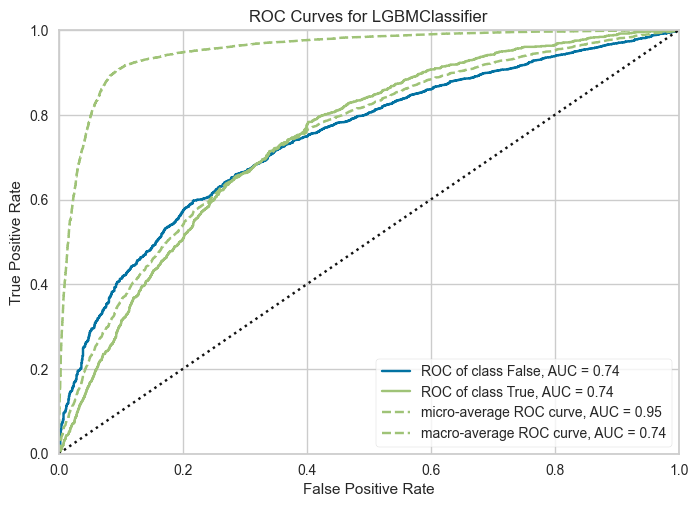

In [76]:
plot_model(tuned_lightgbm, plot = 'auc')

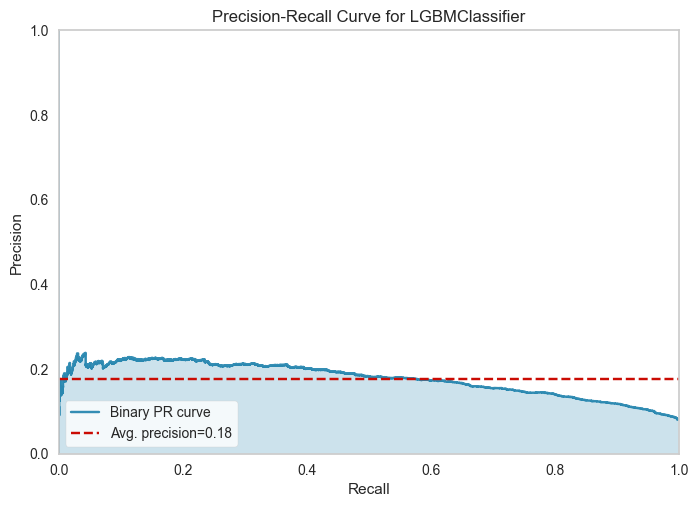

In [77]:
plot_model(tuned_lightgbm, plot = 'pr')

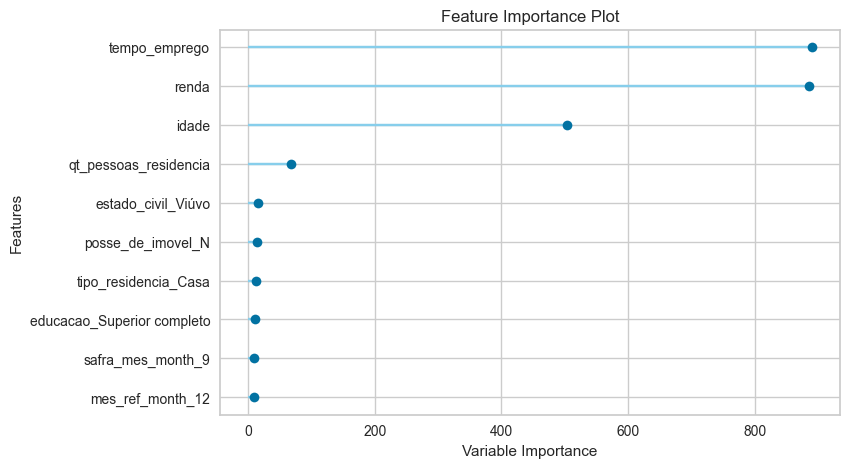

In [78]:
plot_model(tuned_lightgbm, plot='feature')

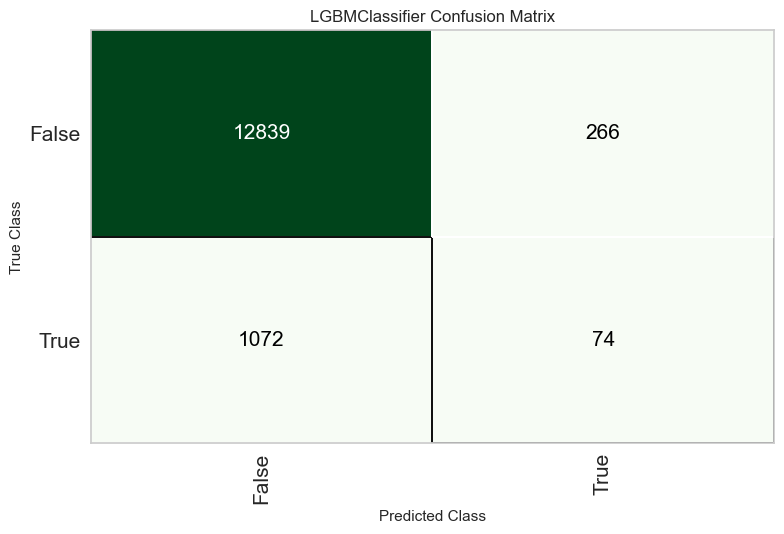

In [79]:
plot_model(tuned_lightgbm, plot = 'confusion_matrix')

In [80]:
evaluate_model(tuned_lightgbm)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Hyperparameters', 'param…

In [81]:
final_lightgbm = finalize_model(tuned_lightgbm)

In [82]:
#Parâmetros finais do modelo Random Forest para deploy
print(final_lightgbm)

LGBMClassifier(bagging_fraction=0.9, bagging_freq=3, boosting_type='gbdt',
               class_weight=None, colsample_bytree=1.0, feature_fraction=0.5,
               importance_type='split', learning_rate=0.4, max_depth=-1,
               min_child_samples=6, min_child_weight=0.001, min_split_gain=0.3,
               n_estimators=20, n_jobs=-1, num_leaves=150, objective=None,
               random_state=123, reg_alpha=0.005, reg_lambda=0.0005,
               subsample=1.0, subsample_for_bin=200000, subsample_freq=0)


In [83]:
predict_model(final_lightgbm);

[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9275,0.9016,0.2033,0.6601,0.3109,0.2837,0.3397


In [84]:
unseen_predictions = predict_model(final_lightgbm, data=data_unseen)
unseen_predictions.head()

[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9120,0.7528,0.0863,0.2982,0.1339,0.1021,0.1244


,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,safra_mes,mes_ref,tempo_emprego_missing,Label,Score
0,M,S,S,0,Pensionista,Superior completo,Casado,Casa,63,0.000000,2.0,6858.92,False,2015-02-01,2015-02-01,1,False,0.9182
1,F,N,S,0,Pensionista,Médio,União,Casa,62,0.000000,2.0,11010.51,False,2015-02-01,2015-02-01,1,False,0.9675
2,F,S,S,0,Assalariado,Médio,Solteiro,Com os pais,32,0.780822,1.0,921.45,False,2015-02-01,2015-02-01,0,False,0.9156
3,M,S,N,1,Assalariado,Superior completo,Casado,Casa,33,4.331507,3.0,3985.13,False,2015-10-01,2015-10-01,0,False,0.9533
4,M,S,S,1,Assalariado,Superior completo,Casado,Estúdio,50,7.191781,3.0,8891.62,False,2015-08-01,2015-08-01,0,False,0.9838


In [85]:
from pycaret.utils import check_metric
check_metric(unseen_predictions['mau'].astype(str), unseen_predictions['Label'], metric = 'Accuracy')

0.912

In [86]:
save_model(final_lightgbm,'Final lightgbm Model 30Mar2026')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=None,
          steps=[('dtypes',
                  DataTypes_Auto_infer(categorical_features=[],
                                       display_types=True, features_todrop=[],
                                       id_columns=[],
                                       ml_usecase='classification',
                                       numerical_features=[], target='mau',
                                       time_features=[])),
                 ('imputer',
                  Simple_Imputer(categorical_strategy='not_available',
                                 fill_value_categorical=None,
                                 fill_value_numerical=None,
                                 numeric_strategy...
                                 boosting_type='gbdt', class_weight=None,
                                 colsample_bytree=1.0, feature_fraction=0.5,
                                 importance_type='split', learning_rate=0.4,
                                 max_depth=-1,

In [87]:
saved_final_lightgbm = load_model('Final lightgbm Model 30Mar2026')

Transformation Pipeline and Model Successfully Loaded


In [88]:
new_prediction = predict_model(saved_final_lightgbm, data=data_unseen)

[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.5, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.5
[LightGBM] [Warning] bagging_fraction is set=0.9, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9120,0.7528,0.0863,0.2982,0.1339,0.1021,0.1244


In [89]:
new_prediction.head()

,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,safra_mes,mes_ref,tempo_emprego_missing,Label,Score
0,M,S,S,0,Pensionista,Superior completo,Casado,Casa,63,0.000000,2.0,6858.92,False,2015-02-01,2015-02-01,1,False,0.9182
1,F,N,S,0,Pensionista,Médio,União,Casa,62,0.000000,2.0,11010.51,False,2015-02-01,2015-02-01,1,False,0.9675
2,F,S,S,0,Assalariado,Médio,Solteiro,Com os pais,32,0.780822,1.0,921.45,False,2015-02-01,2015-02-01,0,False,0.9156
3,M,S,N,1,Assalariado,Superior completo,Casado,Casa,33,4.331507,3.0,3985.13,False,2015-10-01,2015-10-01,0,False,0.9533
4,M,S,S,1,Assalariado,Superior completo,Casado,Estúdio,50,7.191781,3.0,8891.62,False,2015-08-01,2015-08-01,0,False,0.9838


In [90]:
from pycaret.utils import check_metric
check_metric(new_prediction['mau'].astype(str), new_prediction['Label'], metric = 'Accuracy')

0.912

In [91]:
saved_final_lightgbm.named_steps

{'dtypes': DataTypes_Auto_infer(categorical_features=[], display_types=True,
                      features_todrop=[], id_columns=[],
                      ml_usecase='classification', numerical_features=[],
                      target='mau', time_features=[]),
 'imputer': Simple_Imputer(categorical_strategy='not_available',
                fill_value_categorical=None, fill_value_numerical=None,
                numeric_strategy='mean', target_variable=None),
 'new_levels1': New_Catagorical_Levels_in_TestData(replacement_strategy='least frequent',
                                    target='mau'),
 'ordinal': 'passthrough',
 'cardinality': 'passthrough',
 'znz': 'passthrough',
 'club_R_L': 'passthrough',
 'new_levels': New_Catagorical_Levels_in_TestData(replacement_strategy='least frequent',
                                    target='mau'),
 'feature_time': Make_Time_Features(list_of_features=None,
                    time_feature=Index(['safra_mes', 'mes_ref'], dtype='object')),
 'gr

<font color="orange">
Ao longo do exercício, foram realizadas etapas de tratamento de dados, seleção de variáveis, redução de dimensionalidade e modelagem preditiva.  

A utilização do PyCaret permitiu estruturar e automatizar o processo de modelagem, facilitando a comparação entre algoritmos e o ajuste de hiperparâmetros.

O modelo LightGBM apresentou bom desempenho, com capacidade consistente de discriminação entre as classes e estabilidade na validação em dados não vistos.

Além disso, as análises gráficas contribuíram para uma melhor interpretação do modelo, permitindo compreender tanto seu desempenho quanto os principais fatores que influenciam suas previsões.  

De forma geral, o modelo desenvolvido se mostra adequado para o problema proposto, atendendo aos objetivos da tarefa e demonstrando boa capacidade preditiva.


</font >